# YIELDS — Maize Crop Model + PROSAIL Pipeline
## Spatially-explicit yield estimation at 30 m resolution

**Architecture:**
```
yields_data_io.py          ← all API / data-fetch functions (imported below)
         │
         ▼
[this notebook]
   1. Config & imports
   2. Fetch inputs  (weather · ET · soil)   ← calls yields_data_io
   3. Visualise inputs
   4. Crop model    (thermal time · water balance · biomass)
   5. Crop model outputs & plots
   6. PROSAIL RT    (canopy state → simulated Landsat reflectance)
   7. Spectral outputs & plots
```



---
## Section 0 — Imports

In [1]:
# ── Standard library ─────────────────────────────────────────────────────────
import os, copy, warnings
from datetime import timedelta

# ── Numerical / data ──────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
sns.set_theme(style="white")
plt.rcParams.update({
    "font.size": 11, "axes.titlesize": 12, "axes.labelsize": 11,
    "xtick.labelsize": 10, "ytick.labelsize": 10, "legend.fontsize": 9,
    "axes.linewidth": 0.8, "lines.linewidth": 1.8, "figure.dpi": 150,
})

# ── YIELDS data-I/O library ──────────────────────────────────────────────────
# All API calls (Mesonet weather, OpenET, gSSURGO soil) live in yields_data_io.py
# Place yields_data_io.py in the same directory as this notebook.
from yields_data_io import (
    fetch_weather_from_mesonet,
    build_grid_centroids,
    fetch_et_stack_from_openet,
    generate_et_stack_synthetic,
    fetch_ssurgo_soil_for_bbox,
    assign_mukeys_to_grid,
    build_ssurgo_soil_layers_grid,
)

# ── Optional: PROSAIL radiative transfer ──────────────────────────────────────
try:
    from prosail import run_prosail
    from pvlib.solarposition import get_solarposition
    PROSAIL_AVAILABLE = True
    print("PROSAIL + pvlib loaded.")
except ImportError:
    warnings.warn("PROSAIL / pvlib not installed. Section 6 will be skipped.\n"
                  "Install with: pip install prosail pvlib")
    PROSAIL_AVAILABLE = False

print("All imports complete.")


PROSAIL + pvlib loaded.
All imports complete.


---
## Section 1 — Configuration
Edit **only this cell** to change the study area, dates, or API keys.

In [2]:
# ── API credentials ───────────────────────────────────────────────────────────
# Store keys in environment variables rather than hard-coding them.
# Set once in your terminal: export OPENET_API_KEY="your_key_here"
OPENET_API_KEY = os.environ.get("OPENET_API_KEY", "ecf3f86c97ac90b4f1ab77f859ae8369")

# ── Study area ────────────────────────────────────────────────────────────────
# Central Kansas test site (Ellsworth County)
BBOX = {"min_lon": -98.55, "min_lat": 38.30, "max_lon": -98.50, "max_lat": 38.35}
SITE_LAT, SITE_LON = 38.32, -98.52          # for solar geometry in PROSAIL

# ── Grid dimensions ──────────────────────────────────────────────────────────
GRID_ROWS = 3                                # spatial rows  (N→S)
GRID_COLS = 3                                # spatial cols  (W→E)

# ── Simulation period ─────────────────────────────────────────────────────────
PLANTING_DATE = "2025-05-15"                 # first day of simulation
SEASON_LENGTH = 180                          # days to simulate
YEAR          = 2025                         # year used to filter Mesonet data

# ── Mesonet weather station ───────────────────────────────────────────────────
MESONET_STATION = "Manhattan"               # nearest Mesonet station name

# ── Derived (do not edit) ─────────────────────────────────────────────────────
START_DATE = pd.to_datetime(PLANTING_DATE)
END_DATE   = START_DATE + timedelta(days=SEASON_LENGTH - 1)

print(f"Study period : {START_DATE.date()} → {END_DATE.date()} ({SEASON_LENGTH} days)")
print(f"Bounding box : {BBOX}")
print(f"Grid         : {GRID_ROWS}×{GRID_COLS} = {GRID_ROWS*GRID_COLS} cells")
print(f"OpenET key   : {'*** (env)' if os.environ.get('OPENET_API_KEY') else 'hard-coded (rotate this!)'}")


Study period : 2025-05-15 → 2025-11-10 (180 days)
Bounding box : {'min_lon': -98.55, 'min_lat': 38.3, 'max_lon': -98.5, 'max_lat': 38.35}
Grid         : 3×3 = 9 cells
OpenET key   : hard-coded (rotate this!)


---
## Section 2 — Fetch Input Data

Three spatially-explicit inputs feed the crop model:

| Input | Source | Spatial treatment |
|---|---|---|
| Weather (T, rad, rain) | Kansas Mesonet | Uniform per site (weather doesn't vary meaningfully at 30 m) |
| Evapotranspiration | OpenET Ensemble | **Per-pixel** 30 m (key spatial driver) |
| Soil (θ_fc, θ_wp) | gSSURGO via SDA | **Per-pixel** 30 m (key spatial driver) |


### 2a — Weather (Kansas Mesonet)

In [3]:
weather_df, weather_data = fetch_weather_from_mesonet(
    station      = MESONET_STATION,
    start        = "2025-01-01",        # wide pull; filtered to YEAR below
    end          = "2025-12-31",
    year_filter  = YEAR,
    planting_date= PLANTING_DATE,
)
weather_df.head()


Weather loaded: 231 days  (2025-05-15 → 2025-12-31)


,DATE,T_mean,TMIN,TMAX,rain,solar_rad,year
0,2025-05-15,24.72,17.29,31.20,0.0,25.63,2025
1,2025-05-16,22.19,14.57,28.39,0.0,27.20,2025
2,2025-05-17,20.49,13.55,27.07,0.0,27.22,2025
3,2025-05-18,18.99,9.95,26.53,0.0,28.38,2025
4,2025-05-19,20.28,14.11,26.55,0.0,20.45,2025


### 2b — Evapotranspiration (OpenET)

In [4]:
# Build the 30 m grid centroid coordinates
grid_lats, grid_lons = build_grid_centroids(BBOX, GRID_ROWS, GRID_COLS)
print(f"Grid centroids: {grid_lats.shape}")
print(f"  Lat {grid_lats.min():.4f} → {grid_lats.max():.4f}")
print(f"  Lon {grid_lons.min():.4f} → {grid_lons.max():.4f}")

# Fetch ET — one POST request per cell (point timeseries endpoint)
# For a full field, switch to fetch_et_raster_for_polygon() in yields_data_io.py
print("\nQuerying OpenET (this takes ~5 s per cell) ...")
ET_stack, api_ok = fetch_et_stack_from_openet(
    grid_lats, grid_lons,
    start_date    = PLANTING_DATE,
    end_date      = END_DATE.strftime("%Y-%m-%d"),
    api_key       = OPENET_API_KEY,
    season_length = SEASON_LENGTH,
)

if not api_ok:
    warnings.warn("OpenET returned no data — using synthetic ET fallback (offline testing only).")
    ET_stack       = generate_et_stack_synthetic(GRID_ROWS, GRID_COLS, SEASON_LENGTH)
    DATA_SOURCE_ET = "Synthetic (OpenET unavailable)"
else:
    DATA_SOURCE_ET = "OpenET Ensemble API"

print(f"\nET stack shape : {ET_stack.shape}  (days × rows × cols)")
print(f"ET range       : {np.nanmin(ET_stack):.2f} – {np.nanmax(ET_stack):.2f} mm/day")
print(f"ET mean        : {np.nanmean(ET_stack):.2f} mm/day")
print(f"Source         : {DATA_SOURCE_ET}")


Grid centroids: (3, 3)
  Lat 38.3000 → 38.3500
  Lon -98.5500 → -98.5000

Querying OpenET (this takes ~5 s per cell) ...
  [OpenET] cell (0,0)  lat=38.3500  lon=-98.5500
  [OpenET] cell (0,1)  lat=38.3500  lon=-98.5250
  [OpenET] cell (0,2)  lat=38.3500  lon=-98.5000
  [OpenET] cell (1,0)  lat=38.3250  lon=-98.5500
  [OpenET] cell (1,1)  lat=38.3250  lon=-98.5250
  [OpenET] cell (1,2)  lat=38.3250  lon=-98.5000


C:\Users\kelechi\OneDrive - Kansas State University\Desktop\Research Resources\Grants\NASA FINESST\2026\Preliminary\yields_data_io.py:230: UserWarning: OpenET: HTTP 500 for (38.3250, -98.5000) — Internal Server Error
  warnings.warn(f"OpenET: HTTP {code} for ({lat:.4f}, {lon:.4f}) — {body_txt}")


  [OpenET] cell (2,0)  lat=38.3000  lon=-98.5500
  [OpenET] cell (2,1)  lat=38.3000  lon=-98.5250
  [OpenET] cell (2,2)  lat=38.3000  lon=-98.5000

ET stack shape : (180, 3, 3)  (days × rows × cols)
ET range       : 0.22 – 9.17 mm/day
ET mean        : 3.42 mm/day
Source         : OpenET Ensemble API


### 2c — Soil (gSSURGO via SDA)

In [5]:
soil_df = fetch_ssurgo_soil_for_bbox(BBOX, debug=False)

if soil_df is not None and len(soil_df) > 0:
    DATA_SOURCE_SOIL  = "gSSURGO SDA API"
    mukey_grid        = assign_mukeys_to_grid(grid_lats, grid_lons, soil_df)
    soil_layers_grid, soil_summary_grid = build_ssurgo_soil_layers_grid(soil_df, mukey_grid)
else:
    warnings.warn("SDA unavailable — using uniform synthetic soil (offline testing only).")
    DATA_SOURCE_SOIL  = "Synthetic"
    # Synthetic fallback: uniform silty clay loam
    soil_layers_grid  = [
        [
            [{"depth": d/100, "theta_fc": 0.30, "theta_wp": 0.12, "label": f"L{k}"}
             for k, d in enumerate([15,15,30,40,100])]
            for j in range(GRID_COLS)
        ]
        for i in range(GRID_ROWS)
    ]
    soil_summary_grid = {
        "theta_fc": np.full((GRID_ROWS, GRID_COLS), 0.30),
        "theta_wp": np.full((GRID_ROWS, GRID_COLS), 0.12),
    }

print(f"Soil source : {DATA_SOURCE_SOIL}")
print(f"θ_fc range  : {soil_summary_grid['theta_fc'].min():.3f} – {soil_summary_grid['theta_fc'].max():.3f} m³/m³")
print(f"θ_wp range  : {soil_summary_grid['theta_wp'].min():.3f} – {soil_summary_grid['theta_wp'].max():.3f} m³/m³")


[SDA] Querying gSSURGO for soil horizons...
  96 horizon records across 16 map units.
Soil source : gSSURGO SDA API
θ_fc range  : 0.186 – 0.335 m³/m³
θ_wp range  : 0.089 – 0.210 m³/m³


---
## Section 3 — Visualise Input Data
Confirm that all three input layers look sensible before running the model.

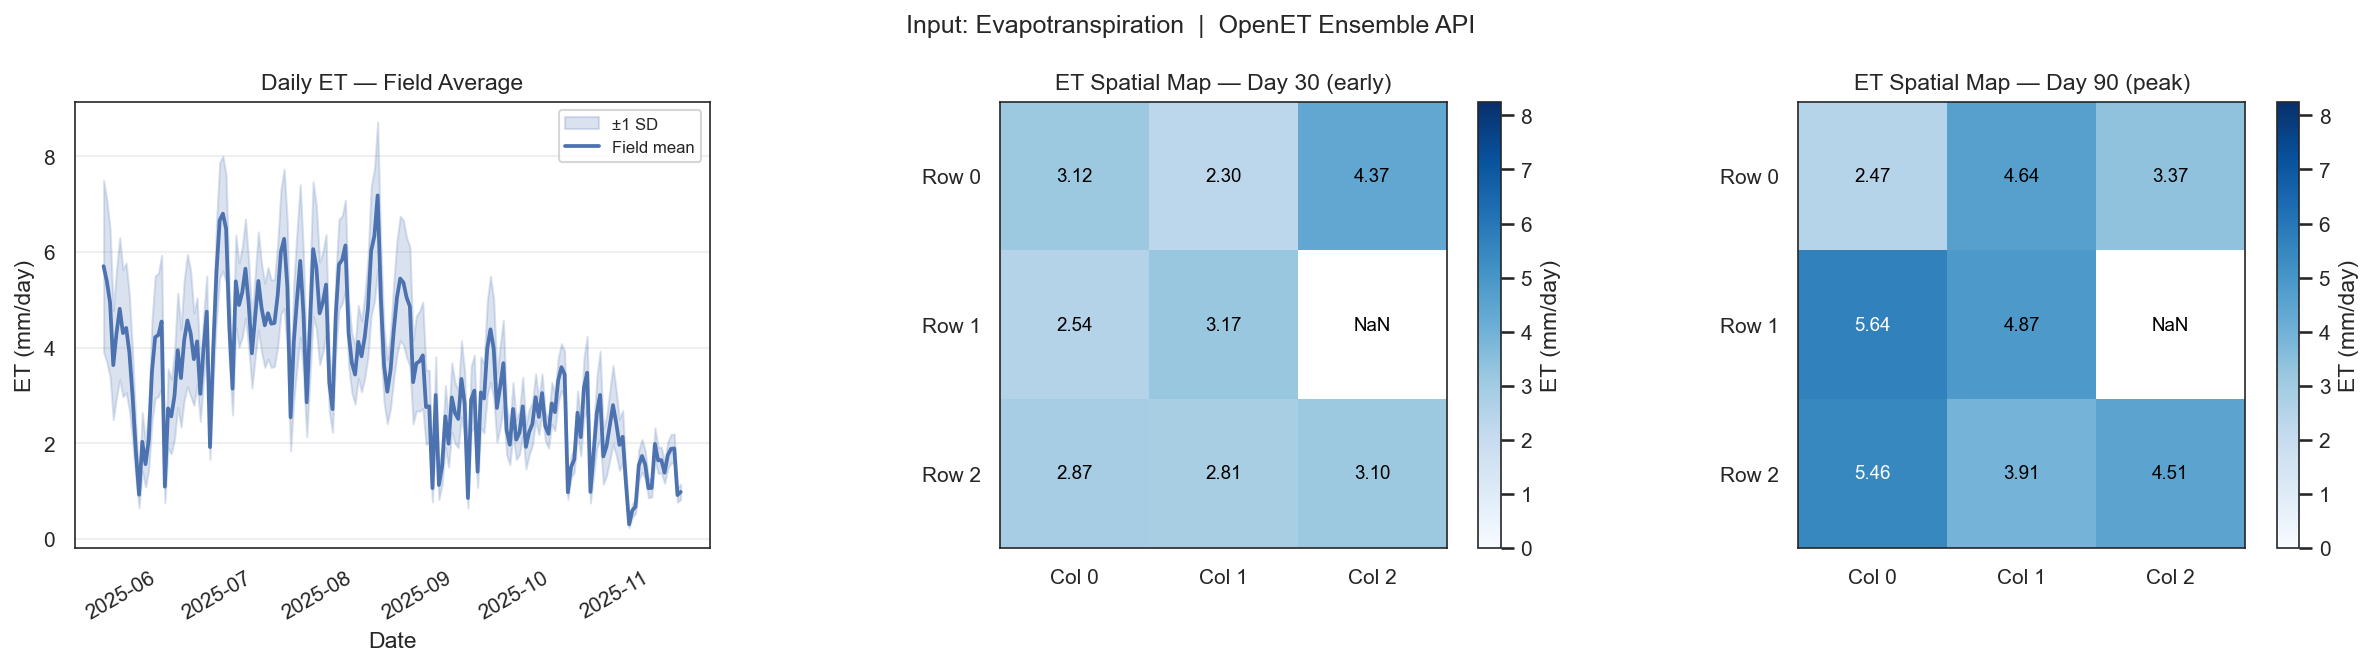

In [6]:
# ── Plot 3.1: ET — time series + spatial snapshots ───────────────────────────
date_axis = pd.date_range(PLANTING_DATE, periods=SEASON_LENGTH, freq="D")

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Time series: field mean ± 1 SD
et_mean = np.nanmean(ET_stack, axis=(1, 2))
et_std  = np.nanstd( ET_stack, axis=(1, 2))
axes[0].fill_between(date_axis, et_mean - et_std, et_mean + et_std,
                     color="#4C72B0", alpha=0.2, label="±1 SD")
axes[0].plot(date_axis, et_mean, color="#4C72B0", lw=1.8, label="Field mean")
axes[0].set_xlabel("Date"); axes[0].set_ylabel("ET (mm/day)")
axes[0].set_title("Daily ET — Field Average", fontsize=11)
axes[0].legend(fontsize=8); axes[0].grid(axis="y", alpha=0.3)
plt.setp(axes[0].get_xticklabels(), rotation=30, ha="right")

# Spatial snapshots at day 30 and day 90
for ax, snap_day, label in [
    (axes[1], 30,  "Day 30 (early)"),
    (axes[2], min(90, SEASON_LENGTH-1), "Day 90 (peak)"),
]:
    snap = ET_stack[snap_day]
    vmax = max(np.nanmax(ET_stack) * 0.9, 0.1)
    im   = ax.imshow(snap, cmap="Blues", interpolation="nearest", vmin=0, vmax=vmax)
    plt.colorbar(im, ax=ax, label="ET (mm/day)", fraction=0.046)
    for r in range(snap.shape[0]):
        for c in range(snap.shape[1]):
            v = snap[r, c]
            ax.text(c, r, "NaN" if np.isnan(v) else f"{v:.2f}",
                    ha="center", va="center", fontsize=9,
                    color="white" if (not np.isnan(v) and v > vmax * 0.6) else "black")
    ax.set_title(f"ET Spatial Map — {label}", fontsize=11)
    ax.set_xticks(range(GRID_COLS)); ax.set_xticklabels([f"Col {c}" for c in range(GRID_COLS)])
    ax.set_yticks(range(GRID_ROWS)); ax.set_yticklabels([f"Row {r}" for r in range(GRID_ROWS)])

plt.suptitle(f"Input: Evapotranspiration  |  {DATA_SOURCE_ET}", fontsize=12)
plt.tight_layout(); plt.show()


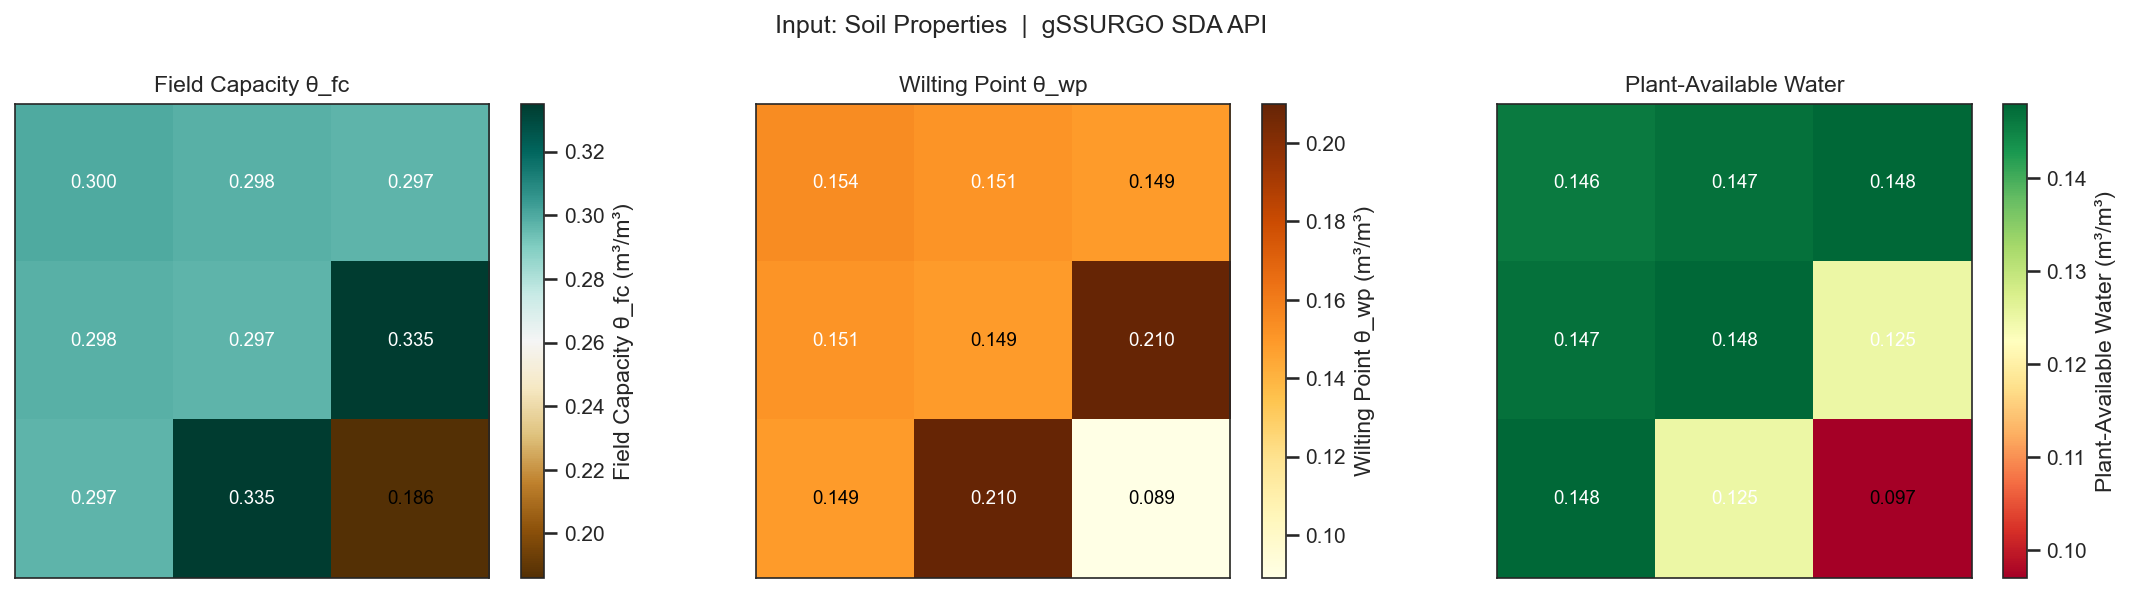

In [7]:
# ── Plot 3.2: Soil spatial properties ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
paw = soil_summary_grid["theta_fc"] - soil_summary_grid["theta_wp"]

for ax, data, cmap, label in [
    (axes[0], soil_summary_grid["theta_fc"], "BrBG",   "Field Capacity θ_fc (m³/m³)"),
    (axes[1], soil_summary_grid["theta_wp"], "YlOrBr", "Wilting Point θ_wp (m³/m³)"),
    (axes[2], paw,                           "RdYlGn", "Plant-Available Water (m³/m³)"),
]:
    vmin, vmax = data.min(), data.max()
    im = ax.imshow(data, cmap=cmap, interpolation="nearest", vmin=vmin, vmax=vmax)
    plt.colorbar(im, ax=ax, label=label, fraction=0.046)
    for r in range(data.shape[0]):
        for c in range(data.shape[1]):
            ax.text(c, r, f"{data[r,c]:.3f}", ha="center", va="center",
                    fontsize=9, color="white" if data[r,c] > (vmin+vmax)/2 else "black")
    ax.set_title(label.split("(")[0].strip(), fontsize=11)
    ax.set_xticks([]); ax.set_yticks([])

plt.suptitle(f"Input: Soil Properties  |  {DATA_SOURCE_SOIL}", fontsize=12)
plt.tight_layout(); plt.show()


C:\Users\kelechi\AppData\Local\Temp\ipykernel_33572\2869208159.py:35: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
C:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


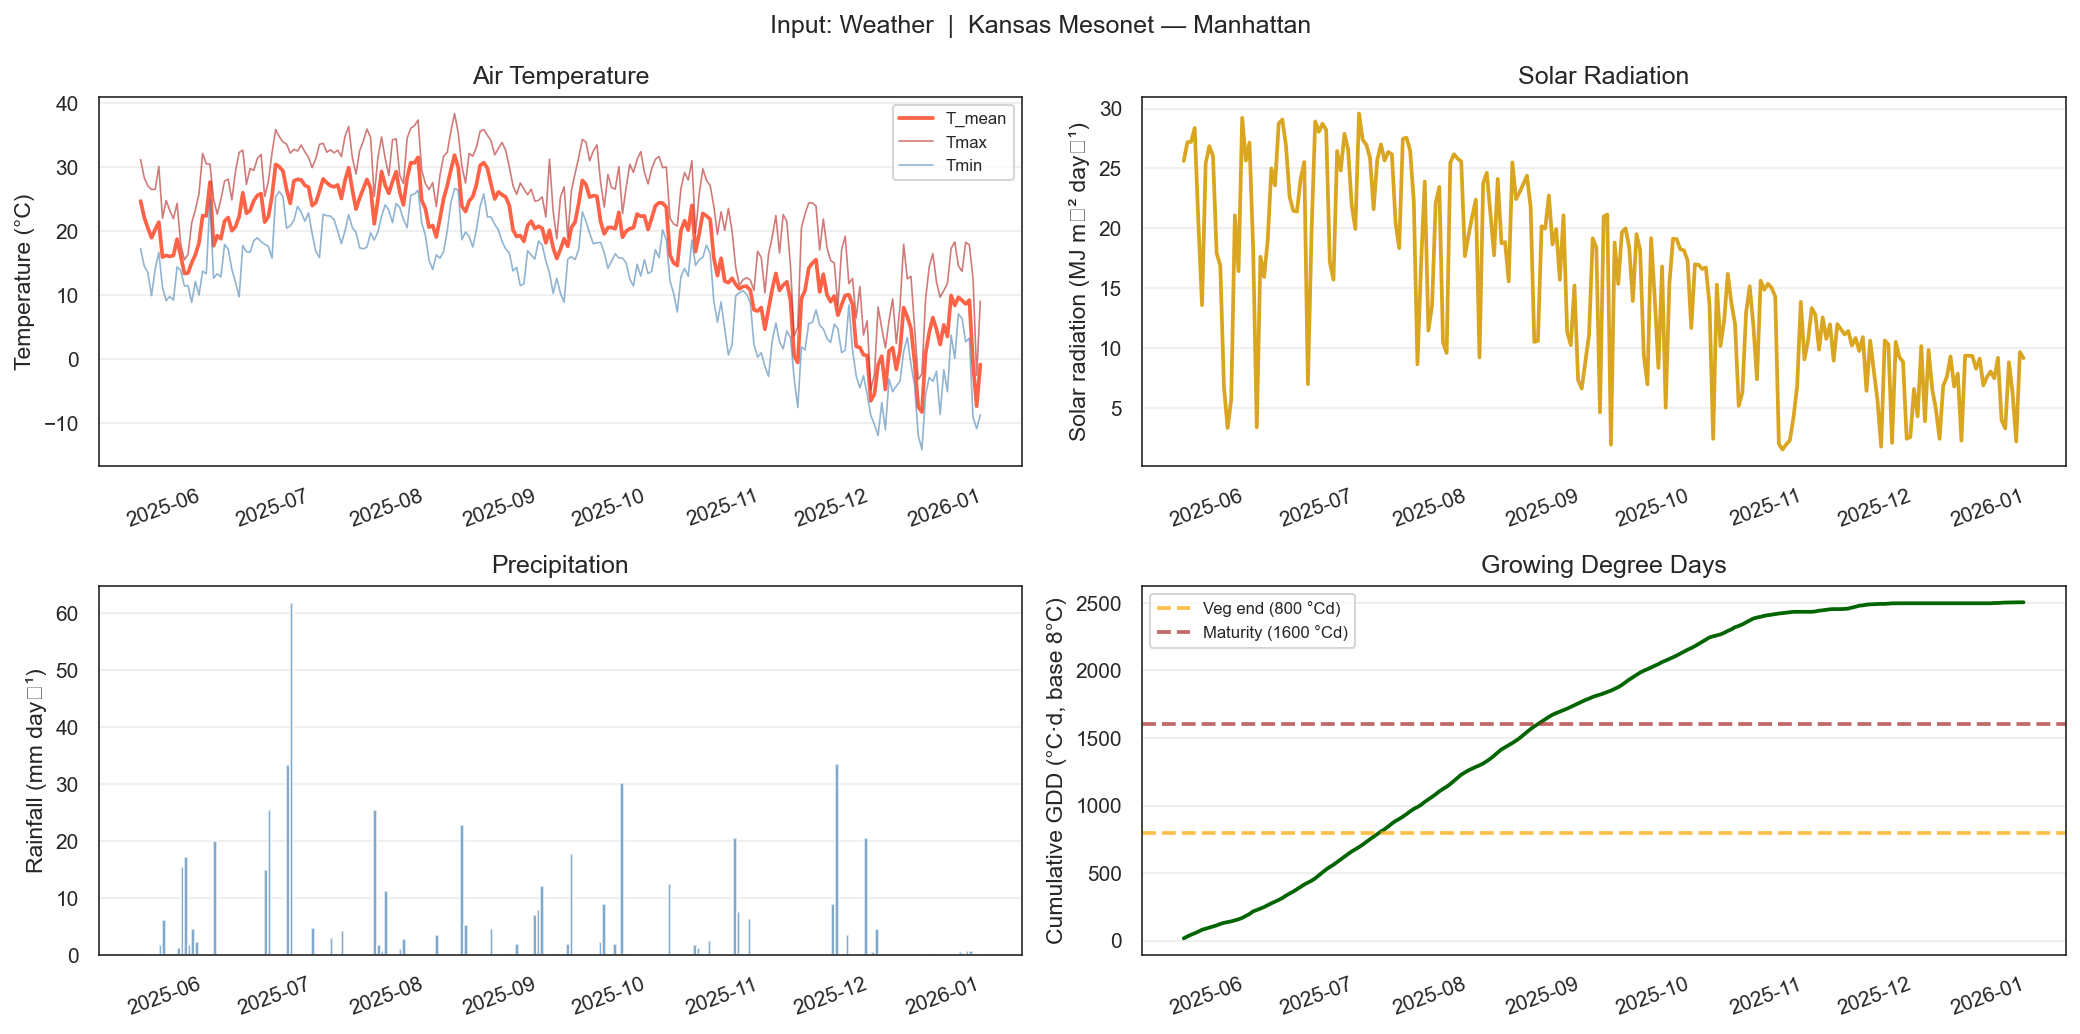

In [8]:
# ── Plot 3.3: Weather seasonal overview ───────────────────────────────────────
wdf = weather_df.copy()
wdf["DATE"] = pd.to_datetime(wdf["DATE"])

fig, axes = plt.subplots(2, 2, figsize=(14, 7))

axes[0,0].plot(wdf["DATE"], wdf["T_mean"],  color="tomato",     label="T_mean")
axes[0,0].plot(wdf["DATE"], wdf["TMAX"],    color="firebrick",  lw=0.8, alpha=0.6, label="Tmax")
axes[0,0].plot(wdf["DATE"], wdf["TMIN"],    color="steelblue",  lw=0.8, alpha=0.6, label="Tmin")
axes[0,0].set_ylabel("Temperature (°C)"); axes[0,0].legend(fontsize=8)
axes[0,0].set_title("Air Temperature")

axes[0,1].plot(wdf["DATE"], wdf["solar_rad"], color="goldenrod")
axes[0,1].set_ylabel("Solar radiation (MJ m⁻² day⁻¹)")
axes[0,1].set_title("Solar Radiation")

axes[1,0].bar(wdf["DATE"], wdf["rain"], color="steelblue", alpha=0.7, width=1)
axes[1,0].set_ylabel("Rainfall (mm day⁻¹)")
axes[1,0].set_title("Precipitation")

# Growing degree days
gdd_daily = (wdf["T_mean"] - 8).clip(lower=0)
gdd_cum   = gdd_daily.cumsum()
axes[1,1].plot(wdf["DATE"], gdd_cum, color="darkgreen")
axes[1,1].axhline(800,  ls="--", color="orange",  alpha=0.7, label="Veg end (800 °Cd)")
axes[1,1].axhline(1600, ls="--", color="brown",   alpha=0.7, label="Maturity (1600 °Cd)")
axes[1,1].set_ylabel("Cumulative GDD (°C·d, base 8°C)")
axes[1,1].set_title("Growing Degree Days"); axes[1,1].legend(fontsize=8)

for ax in axes.flat:
    plt.setp(ax.get_xticklabels(), rotation=20, ha="right")
    ax.grid(axis="y", alpha=0.3)

plt.suptitle(f"Input: Weather  |  Kansas Mesonet — {MESONET_STATION}", fontsize=12)
plt.tight_layout(); plt.show()


---
## Section 4 — Crop Model
Process-based daily model (thermal time · Beer-Lambert light interception ·
Hargreaves ET or OpenET override · multi-layer soil water balance · LUE biomass).

These functions stay in the notebook because they are **modelling** code,
not data-extraction code.  Only API / I/O functions live in `yields_data_io.py`.


In [9]:
# ── Model parameters ──────────────────────────────────────────────────────────
# All crop-level constants. Per-cell soil parameters live in soil_layers_grid.
params = {
    # Thermal time (Wang 1960)
    "T_base": 8,    "T_opt": 30,
    # Phenological TT thresholds °C·d (Ritchie et al. 1993)
    "TT_emergence": 100, "TT_veg_end": 800,
    "TT_grainfill": 1200, "TT_maturity": 1600,
    # Light use efficiency (Monteith 1972)
    "LUE": 3.5,     # g biomass / MJ APAR  (maize: 2.5–4.5)
    "k":   0.6,     # Beer-Lambert extinction (maize: 0.5–0.7)
    # Canopy structure
    "SLA": 0.015,   # m²/g  (LAI = SLA × B_leaf)
    "LAI_max": 7.0,
    # Senescence
    "k_sen": 0.02, "k_sen_max": 0.05,
    # Root system (Gerwitz & Page 1974)
    "Zr_max": 1.2, "root_k": 3.0,
    # Hargreaves ET coefficient (Hargreaves & Samani 1985)
    "ET_coeff": 0.6,
}

initial_state_template = {
    "TT": 0.0, "LAI": 0.1, "B": 0.0,
    "B_leaf": 0.0, "B_grain": 0.0, "Zr": 0.15,
}
print("Parameters set.")


Parameters set.


In [10]:
# ── Model utility functions ───────────────────────────────────────────────────

def root_fraction(layer_depths, Zr, k):
    """Exponential root-depth distribution (Gerwitz & Page 1974). Sums to 1."""
    cum, rf = 0.0, []
    for d in layer_depths:
        z_eff = min(cum + d / 2.0, Zr)
        rf.append(0.0 if cum >= Zr else np.exp(-k * z_eff / Zr))
        cum += d
    rf = np.array(rf)
    return rf / rf.sum() if rf.sum() > 0 else rf


def init_cell_state(template, soil_layers):
    """Initialise state for one grid cell; SM starts at 70% of θ_fc."""
    s = copy.deepcopy(template)
    s["soil_layers"] = soil_layers
    s["SM_layers"]   = [l["theta_fc"] * l["depth"] * 1000 * 0.70 for l in soil_layers]
    return s


def get_f_leaf(stage):
    """Fraction of daily biomass allocated to leaves (Ritchie 1993)."""
    return {"emergence":0.60,"vegetative":0.50,"reproductive":0.20,
            "grain_fill":0.05,"maturity":0.00}[stage]


def get_f_grain(stage):
    """Fraction of daily biomass allocated to grain (Ritchie 1993)."""
    return {"emergence":0.00,"vegetative":0.00,"reproductive":0.30,
            "grain_fill":0.70,"maturity":1.00}[stage]

print("Utility functions defined.")


Utility functions defined.


In [11]:
# ── Daily step function ───────────────────────────────────────────────────────

def step(weather, state, params, ET_override=None):
    """
    Advance one grid cell by one day.

    Six sub-models in sequence:
      1. Thermal time  → phenological stage
      2. Beer-Lambert  → APAR
      3. Hargreaves ET (or OpenET override)
      4. Multi-layer soil water balance
      5. Water stress factor
      6. LUE biomass accumulation + partitioning + senescence

    Parameters
    ----------
    weather     : dict  {T_mean, TMAX, TMIN, solar_rad, rain}
    state       : dict  per-cell crop/soil state
    params      : dict  global model parameters
    ET_override : float observed ET from OpenET (mm/day), or None

    Returns
    -------
    state : dict (updated in-place and returned)
    """
    T    = weather.get("T_mean")
    Tmax = weather.get("TMAX", weather.get("T_max"))
    Tmin = weather.get("TMIN", weather.get("T_min"))
    R    = weather.get("solar_rad", 0)
    rain = weather.get("rain", 0)
    if T is None:
        T = 0.5 * (Tmax + Tmin) if (Tmax and Tmin) else 20.0
    Tmax = Tmax if Tmax is not None else T + 2
    Tmin = Tmin if Tmin is not None else T - 2

    # 1. Thermal time
    state["TT"] += max(0, T - params["T_base"])
    TT = state["TT"]

    # 2. Phenological stage
    if   TT < params["TT_emergence"]: stage = "emergence"
    elif TT < params["TT_veg_end"]:   stage = "vegetative"
    elif TT < params["TT_grainfill"]: stage = "reproductive"
    elif TT < params["TT_maturity"]:  stage = "grain_fill"
    else:                             stage = "maturity"

    # 3. Light interception (Beer-Lambert; McCree 1971 for PAR fraction)
    fIPAR = 1 - np.exp(-params["k"] * state["LAI"])
    APAR  = fIPAR * 0.48 * R

    # 4. ET
    ET_pot = (params["ET_coeff"] * 0.0023
              * (T + 17.8) * np.sqrt(max(Tmax - Tmin, 0.1)) * max(R, 0))
    ET_act = float(ET_override) if ET_override is not None else ET_pot
    state.update(ET_pot=ET_pot, ET_act=ET_act, ET=ET_act, rainfall=rain)

    # 5. Soil water balance
    state["Zr"] = min(state["Zr"] + 0.02, params["Zr_max"])
    soil  = state["soil_layers"]
    ldeps = [l["depth"] for l in soil]
    rf    = root_fraction(ldeps, state["Zr"], params["root_k"])

    state["SM_layers"][0] += rain
    for k in range(len(soil) - 1):                          # gravity drainage
        cap = soil[k]["theta_fc"] * soil[k]["depth"] * 1000
        if state["SM_layers"][k] > cap:
            state["SM_layers"][k+1] += state["SM_layers"][k] - cap
            state["SM_layers"][k]    = cap

    layer_stress = []
    for k, lyr in enumerate(soil):
        theta = state["SM_layers"][k] / (lyr["depth"] * 1000)
        rng   = lyr["theta_fc"] - lyr["theta_wp"]
        layer_stress.append(np.clip((theta - lyr["theta_wp"]) / rng, 0, 1) if rng > 0 else 0)

    f_water_soil = float(np.clip(np.dot(rf, layer_stress), 0, 1))
    state["f_water_soil"] = f_water_soil

    if ET_override is None:
        ET_act = ET_pot * f_water_soil
        state.update(ET_act=ET_act, ET=ET_act)

    f_water_et = np.clip(ET_act / ET_pot, 0, 1) if ET_pot > 0 else 1.0
    state["f_water_et"] = f_water_et
    f_water = f_water_et if ET_override is not None else f_water_soil
    state["f_water"] = f_water

    uptake = rf * ET_act
    for k, lyr in enumerate(soil):
        state["SM_layers"][k] = max(
            state["SM_layers"][k] - uptake[k],
            lyr["theta_wp"] * lyr["depth"] * 1000,
        )

    state["SM_total"] = sum(state["SM_layers"])
    pd_tot = sum(l["depth"] for l in soil)
    state["VWC"] = state["SM_total"] / (pd_tot * 1000) if pd_tot > 0 else np.nan

    # 6. Biomass
    f_temp = np.clip((T - params["T_base"]) / (params["T_opt"] - params["T_base"]), 0, 1)
    dB     = params["LUE"] * APAR * f_temp * f_water
    dB_leaf= get_f_leaf(stage) * dB

    if stage in ("reproductive", "grain_fill"):
        prog = (TT - params["TT_veg_end"]) / (params["TT_maturity"] - params["TT_veg_end"])
        dB_leaf -= np.clip(params["k_sen"] * prog, 0, params["k_sen_max"]) * state["B_leaf"]

    state["B"]        += dB
    state["B_leaf"]    = max(state["B_leaf"] + dB_leaf, 0)
    state["B_grain"]  += get_f_grain(stage) * dB
    state["LAI"]       = min(params["SLA"] * state["B_leaf"], params["LAI_max"])
    state["stage"]     = stage
    return state

print("step() defined.")


step() defined.


---
## Section 4b — Initialise & Run Spatial Simulation

In [12]:
n_rows, n_cols = GRID_ROWS, GRID_COLS

# Initialise one state dict per cell
states = [
    [init_cell_state(initial_state_template, soil_layers_grid[i][j])
     for j in range(n_cols)]
    for i in range(n_rows)
]
sm_init = np.array([[sum(states[i][j]["SM_layers"]) for j in range(n_cols)] for i in range(n_rows)])
print(f"Initialised {n_rows}×{n_cols} cells.  SM range: {sm_init.min():.0f}–{sm_init.max():.0f} mm")


Initialised 3×3 cells.  SM range: 95–403 mm


In [13]:
# ── Run spatial simulation ────────────────────────────────────────────────────
results      = []
days_to_run  = min(SEASON_LENGTH, len(weather_data))
print(f"Running {n_rows}×{n_cols} grid for {days_to_run} days ...")

for day in range(days_to_run):
    wx = weather_data[day]
    for i in range(n_rows):
        for j in range(n_cols):
            et_val      = ET_stack[day, i, j]
            ET_override = None if np.isnan(et_val) else et_val
            states[i][j] = step(wx, states[i][j], params, ET_override)
            s = states[i][j]
            results.append({
                "day": day, "i": i, "j": j,
                "DATE":         pd.to_datetime(wx["DATE"]).date(),
                "theta_fc":     s["soil_layers"][0]["theta_fc"],
                "theta_wp":     s["soil_layers"][0]["theta_wp"],
                "stage":        s["stage"], "TT": s["TT"],
                "LAI":          s["LAI"],   "Biomass": s["B"],
                "Leaf_Biomass": s["B_leaf"],"Grain":   s["B_grain"],
                "ET":           s["ET"],    "ET_pot":  s["ET_pot"],
                "f_water":      s["f_water"],
                "f_water_soil": s["f_water_soil"],
                "f_water_et":   s["f_water_et"],
                "Zr":           s["Zr"],    "SM_total":s["SM_total"],
                "VWC":          s["VWC"],   "Rainfall":s["rainfall"],
            })

df = pd.DataFrame(results)
df["pixel_id"] = df["i"].astype(str) + "_" + df["j"].astype(str)
print(f"Done. Output: {df.shape[0]:,} rows × {df.shape[1]} cols")
df.head()


Running 3×3 grid for 180 days ...
Done. Output: 1,620 rows × 22 cols


,day,i,j,DATE,theta_fc,theta_wp,stage,TT,LAI,Biomass,...,ET,ET_pot,f_water,f_water_soil,f_water_et,Zr,SM_total,VWC,Rainfall,pixel_id
0,0,0,0,2025-05-15,0.300,0.154,emergence,16.72,0.017151,1.905720,...,7.444,5.608988,1.000000,0.391806,1.000000,0.17,389.456,0.194728,0.0,0_0
1,0,0,1,2025-05-15,0.298,0.151,emergence,16.72,0.009489,1.054281,...,3.103,5.608988,0.553219,0.392094,0.553219,0.17,387.504,0.193752,0.0,0_1
2,0,0,2,2025-05-15,0.297,0.149,emergence,16.72,0.017151,1.905720,...,7.931,5.608988,1.000000,0.397973,1.000000,0.17,395.129,0.197564,0.0,0_2
3,0,1,0,2025-05-15,0.298,0.151,emergence,16.72,0.008418,0.935364,...,2.753,5.608988,0.490819,0.392094,0.490819,0.17,387.854,0.193927,0.0,1_0
4,0,1,1,2025-05-15,0.297,0.149,emergence,16.72,0.016876,1.875145,...,5.519,5.608988,0.983956,0.397973,0.983956,0.17,397.541,0.198770,0.0,1_1


---
## Section 5 — Crop Model Outputs

In [14]:
# ── Stage colour map (reused across all plots) ────────────────────────────────
stage_colors = {
    "emergence":    "#B4C9A8",
    "vegetative":   "#2D5A27",
    "reproductive": "#FFD700",
    "grain_fill":   "#E2A13D",
    "maturity":     "#8B5A2B",
}

def add_stage_shading(axes_list, df):
    for stage in ["emergence","vegetative","reproductive","grain_fill","maturity"]:
        sub = df[df["stage"] == stage]
        if sub.empty: continue
        col = stage_colors[stage]
        for ax in axes_list:
            ax.axvspan(sub["day"].min(), sub["day"].max(), color=col, alpha=0.08)

print("Stage colours defined.")


Stage colours defined.


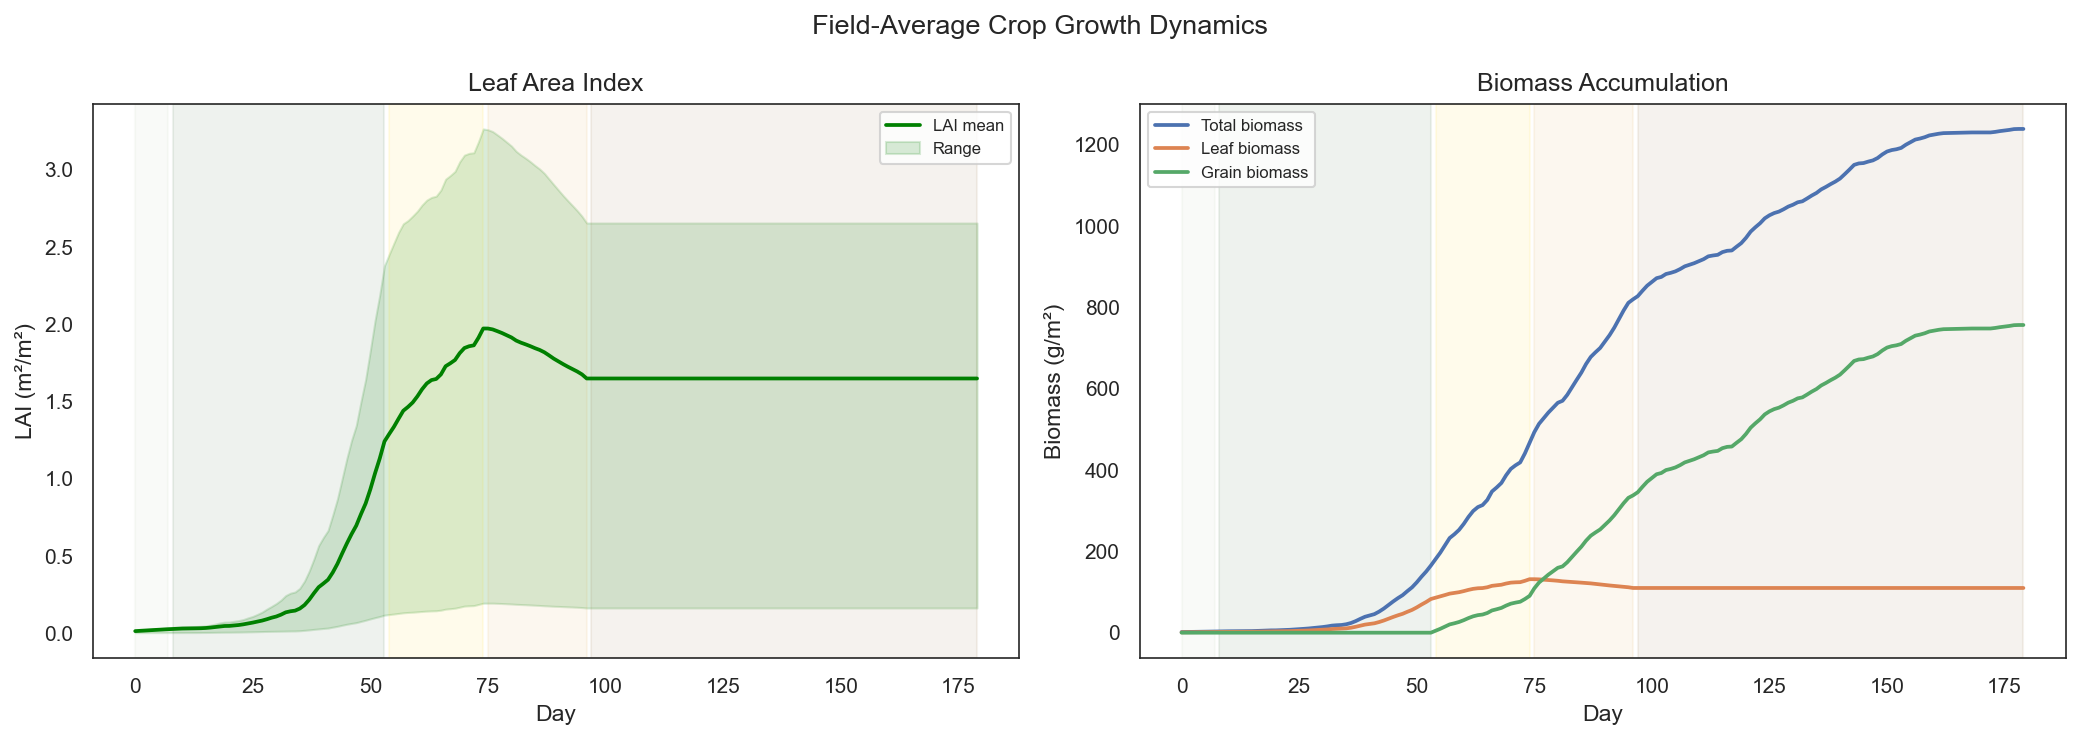

In [15]:
# ── Plot 5.1: LAI and Biomass trajectories ────────────────────────────────────
lai  = df.groupby("day")["LAI"].agg(["mean","min","max"])
bio  = df.groupby("day")[["Biomass","Leaf_Biomass","Grain"]].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(lai.index, lai["mean"], color="green", label="LAI mean")
axes[0].fill_between(lai.index, lai["min"], lai["max"], color="green", alpha=0.15, label="Range")
axes[0].set_xlabel("Day"); axes[0].set_ylabel("LAI (m²/m²)")
axes[0].set_title("Leaf Area Index"); axes[0].legend(fontsize=8)

axes[1].plot(bio.index, bio["Biomass"],       label="Total biomass")
axes[1].plot(bio.index, bio["Leaf_Biomass"],  label="Leaf biomass")
axes[1].plot(bio.index, bio["Grain"],         label="Grain biomass")
axes[1].set_xlabel("Day"); axes[1].set_ylabel("Biomass (g/m²)")
axes[1].set_title("Biomass Accumulation"); axes[1].legend(fontsize=8)

add_stage_shading(axes, df)
plt.suptitle("Field-Average Crop Growth Dynamics", fontsize=13)
plt.tight_layout(); plt.show()


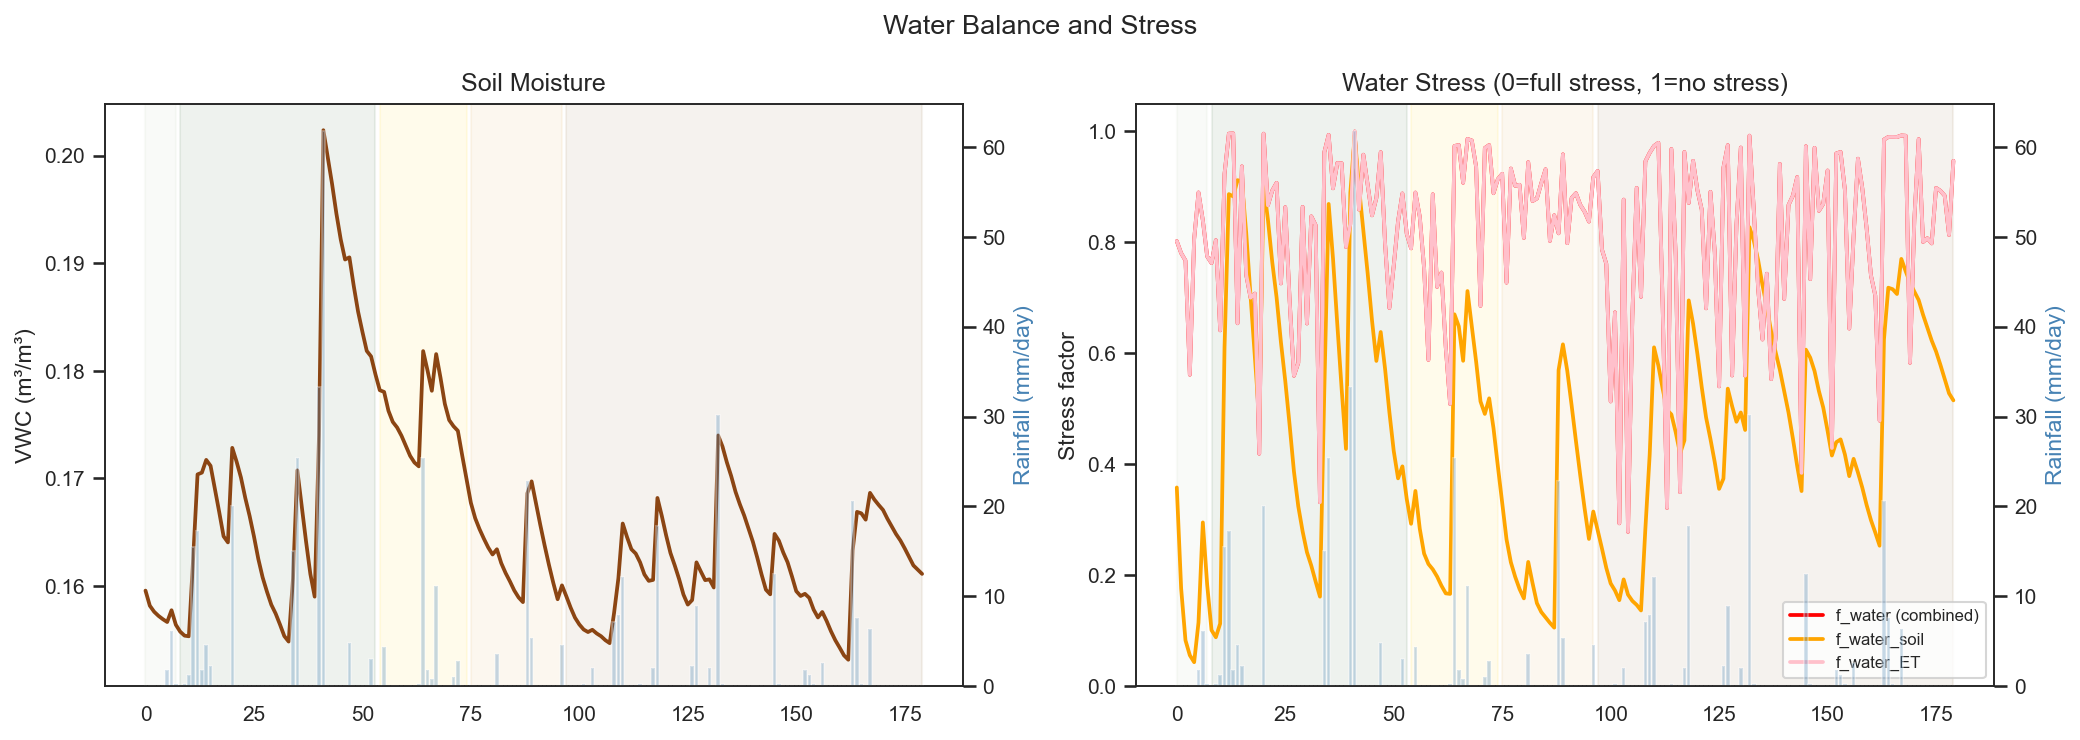

In [16]:
# ── Plot 5.2: Soil moisture and water stress ──────────────────────────────────
sm = df.groupby("day")[["VWC","f_water","f_water_soil","f_water_et","Rainfall"]].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(sm.index, sm["VWC"], color="saddlebrown", label="VWC")
axes[0].set_ylabel("VWC (m³/m³)"); axes[0].set_title("Soil Moisture")
ax0r = axes[0].twinx()
ax0r.bar(sm.index, sm["Rainfall"], color="steelblue", alpha=0.3)
ax0r.set_ylabel("Rainfall (mm/day)", color="steelblue")

axes[1].plot(sm.index, sm["f_water"],       color="red",    label="f_water (combined)")
axes[1].plot(sm.index, sm["f_water_soil"],  color="orange", label="f_water_soil")
axes[1].plot(sm.index, sm["f_water_et"],    color="pink",   label="f_water_ET")
axes[1].set_ylim(0, 1.05); axes[1].set_ylabel("Stress factor")
axes[1].set_title("Water Stress (0=full stress, 1=no stress)"); axes[1].legend(fontsize=8)
ax1r = axes[1].twinx()
ax1r.bar(sm.index, sm["Rainfall"], color="steelblue", alpha=0.3)
ax1r.set_ylabel("Rainfall (mm/day)", color="steelblue")

add_stage_shading(axes, df)
plt.suptitle("Water Balance and Stress", fontsize=13)
plt.tight_layout(); plt.show()


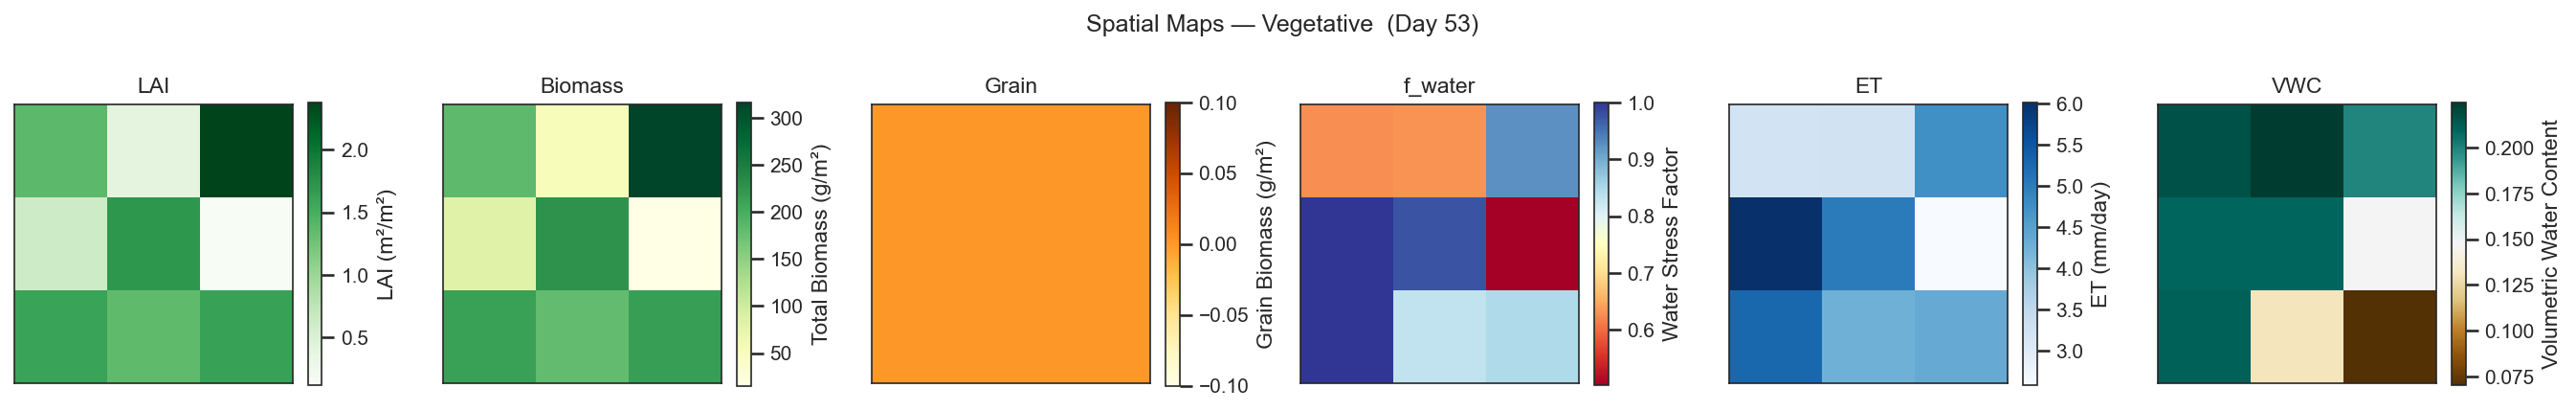

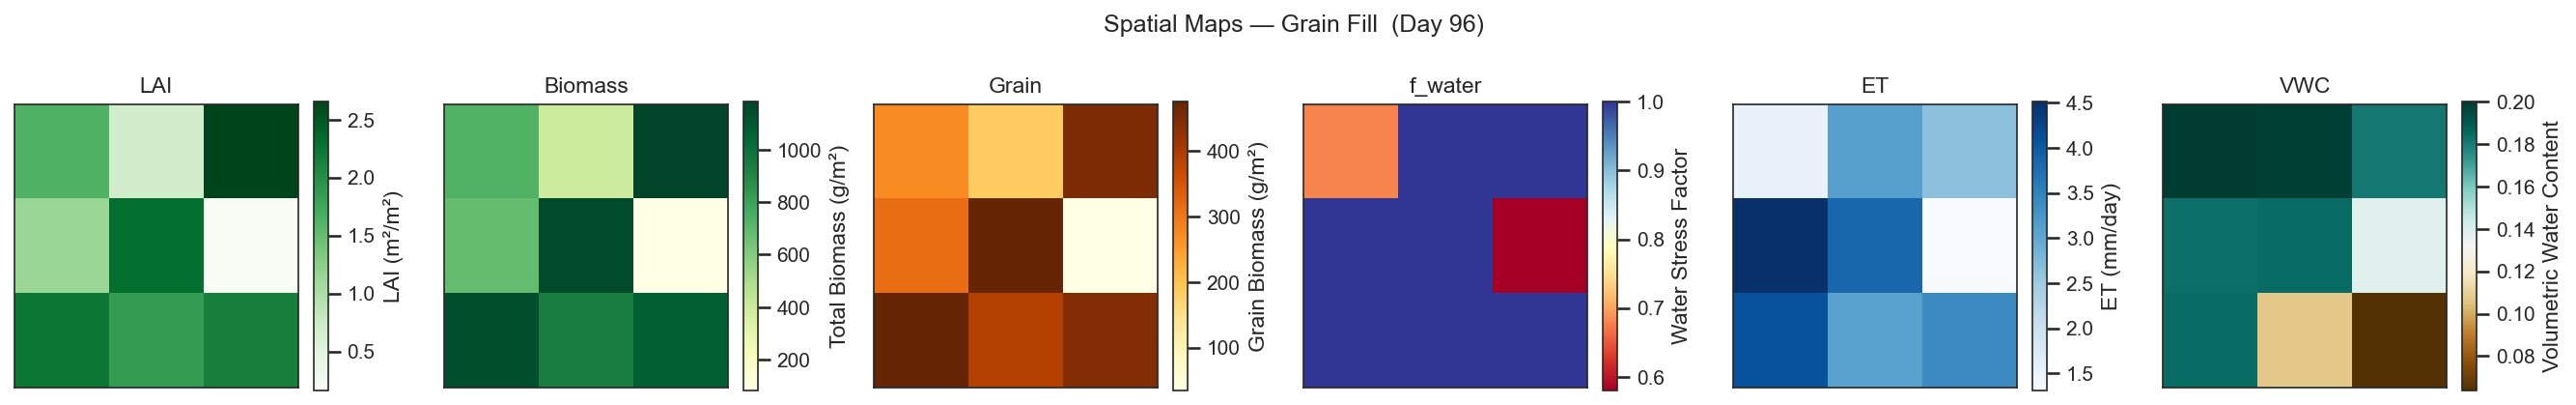

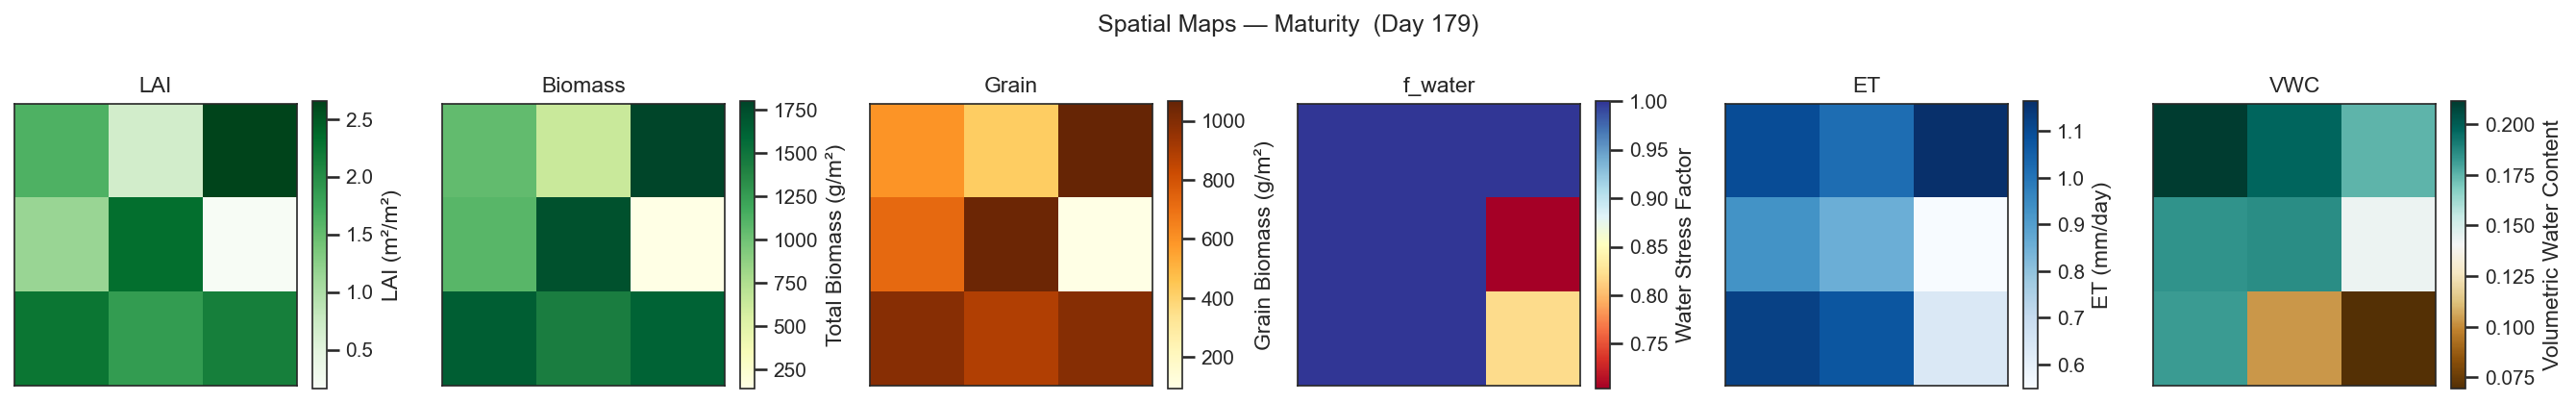

In [22]:
# ── Plot 5.3: Spatial maps by phenological stage ──────────────────────────────
variables = {
    "LAI":     ("Greens",  "LAI (m²/m²)"),
    "Biomass": ("YlGn",    "Total Biomass (g/m²)"),
    "Grain":   ("YlOrBr",  "Grain Biomass (g/m²)"),
    "f_water": ("RdYlBu",  "Water Stress Factor"),
    "ET":      ("Blues",   "ET (mm/day)"),
    "VWC":     ("BrBG",    "Volumetric Water Content"),
}

for stage in ["vegetative", "grain_fill", "maturity"]:
    sub = df[df["stage"] == stage]
    if sub.empty: continue
    df_day = df[df["day"] == sub["day"].max()]

    fig, axes = plt.subplots(1, 6, figsize=(18, 3))
    for ax, (var, (cmap, label)) in zip(axes.flat, variables.items()):
        grid = df_day.pivot(index="i", columns="j", values=var)
        im   = ax.imshow(grid, cmap=cmap, interpolation="nearest")
        plt.colorbar(im, ax=ax, fraction=0.046, label=label)
        ax.set_title(var, fontsize=11); ax.set_xticks([]); ax.set_yticks([])

    plt.suptitle(f"Spatial Maps — {stage.replace('_',' ').title()}  (Day {sub['day'].max()})", fontsize=12)
    plt.tight_layout(); plt.show()


---
## Section 6 — PROSAIL Radiative Transfer Model

**Role in the YIELDS pipeline (Method 3 — DSSAT–PROSAIL hybrid):**

PROSAIL runs *forward* over crop model canopy states to simulate what
**Landsat 8/9** would observe as top-of-canopy reflectance.  Here the
crop model (Section 4) takes the role of DSSAT.  The outputs —
simulated Landsat-band reflectance paired with simulated yield — form
the synthetic lookup table (LUT) used for inversion:

```
Crop model states        PROSAIL forward run       Synthetic LUT
(LAI, Cab, Cw, …)  →→→  (this section)       →→→  (reflectance ↔ yield pairs)
                                                        ↑
                                              Real Landsat SR queries this LUT
                                              to retrieve per-pixel yield
```

**Requires:**  `pip install prosail pvlib`


In [23]:
# ── PROSAIL helper functions ──────────────────────────────────────────────────
# Defined unconditionally; execution is guarded by PROSAIL_AVAILABLE below.

def add_solar_geometry(df, lat=SITE_LAT, lon=SITE_LON):
    """Add solar zenith angle (SZA) per record using pvlib (13:00 local)."""
    if not PROSAIL_AVAILABLE:
        return df
    df = df.copy()
    ts     = pd.to_datetime(df["DATE"]) + pd.Timedelta(hours=13)
    solpos = get_solarposition(ts, lat, lon)
    df["SZA"] = np.clip(solpos["zenith"].values, 0, 85)
    df["VZA"] = 0.0
    df["RAA"] = 0.0
    return df


def map_to_prosail_params(df):
    """
    Map crop model outputs → PROSAIL leaf/canopy parameters.

    Mappings (all literature-derived for maize):
      LAI       → lai_ps   (direct, clamped to 0.01–8)
      B_leaf    → Cab (chlorophyll), Cm (dry matter)  via normalised fraction
      f_water   → Cw (equivalent water thickness)
      stage     → Cbrown (senescence pigment), lidfa (leaf inclination)
      lai_ps    → hspot (hotspot parameter)
    """
    df = df.copy()
    df["lai_ps"] = df["LAI"].clip(0.01, 8)
    if "pixel_id" not in df.columns:
        df["pixel_id"] = df["i"].astype(str) + "_" + df["j"].astype(str)

    max_leaf = df.groupby("pixel_id")["Leaf_Biomass"].transform("max").replace(0, np.nan)
    frac     = (df["Leaf_Biomass"] / max_leaf).fillna(0)

    df["Cab"]    = (10 + 50 * frac).clip(5, 75)
    df["Car"]    = (0.15 * df["Cab"]).clip(0.5, 20)
    df["Cw"]     = (0.003 + 0.015 * df["f_water"]).clip(0.001, 0.02)
    df["Cm"]     = (0.003 + 0.012 * frac).clip(0.001, 0.02)
    df["Cbrown"] = np.select(
        [df["stage"]=="maturity", df["stage"]=="grain_fill"], [0.8, 0.4], default=0.0)
    df["lidfa"]  = np.select(
        [df["stage"]=="emergence", df["stage"]=="vegetative", df["stage"]=="reproductive"],
        [40, 55, 60], default=65)
    df["hspot"]  = (0.01 + 0.1 * (df["lai_ps"] / 8)).clip(0.01, 0.3)
    return df


def build_soil_reflectance(df):
    """
    Dynamic soil background spectrum per record.
    Brightness decreases with soil wetness (Liu et al. 2002).
    Spectral shape: linear ramp 400→2500 nm (Stoner & Baumgardner 1981).
    """
    bright = 0.1 + 0.3 * (1 - df["f_water_soil"].values) ** 1.5
    wl     = np.linspace(400, 2500, 2101)
    base   = 0.1 + 0.4 * (wl - 400) / 2100
    return np.outer(bright, base)                      # (n, 2101)


def run_prosail_grid(df):
    """Run PROSAIL for every row in df. Returns reflectance (n, 2101)."""
    if not PROSAIL_AVAILABLE:
        raise RuntimeError("Install prosail: pip install prosail")
    n    = len(df)
    refl = np.zeros((n, 2101))
    rs   = build_soil_reflectance(df)
    for k in range(n):
        try:
            r = run_prosail(
                n=1.5,
                cab=df["Cab"].iat[k],   car=df["Car"].iat[k],
                cbrown=df["Cbrown"].iat[k], cw=df["Cw"].iat[k],
                cm=df["Cm"].iat[k],     lai=df["lai_ps"].iat[k],
                lidfa=df["lidfa"].iat[k], hspot=df["hspot"].iat[k],
                tts=df["SZA"].iat[k],   tto=df["VZA"].iat[k],
                psi=df["RAA"].iat[k],   rsoil0=rs[k],
            )
            refl[k] = np.clip(r, 0, 1)
        except Exception:
            refl[k] = np.nan
    return refl


# Landsat 8/9 OLI band windows (nm) — replace with full RSR curves for accuracy
LANDSAT_BANDS = {
    "blue":   (452, 512),
    "green":  (533, 590),
    "red":    (636, 673),
    "nir":    (851, 879),
    "swir16": (1566, 1651),
}

def extract_landsat_bands_and_indices(refl):
    """
    Resample PROSAIL full-spectrum output to Landsat 8/9 OLI band averages
    and compute NDVI, NDRE-proxy, and SAVI.

    This is the step that connects PROSAIL output to what real Landsat
    pixels would look like — enabling inversion of real Landsat SR against
    the synthetic LUT for Method 3 of the YIELDS pipeline.
    """
    wl  = np.arange(400, 2501)
    eps = 1e-6
    out = {}
    for name, (lo, hi) in LANDSAT_BANDS.items():
        sel = (wl >= lo) & (wl <= hi)
        out[name] = refl[:, sel].mean(axis=1)

    bdf = pd.DataFrame(out)
    bdf["NDVI"] = (bdf["nir"] - bdf["red"]) / (bdf["nir"] + bdf["red"] + eps)
    bdf["SAVI"] = 1.5 * (bdf["nir"] - bdf["red"]) / (bdf["nir"] + bdf["red"] + 0.5 + eps)
    return bdf

print("PROSAIL helper functions defined.")


PROSAIL helper functions defined.


In [24]:
# ── Run PROSAIL pipeline ──────────────────────────────────────────────────────
if not PROSAIL_AVAILABLE:
    print("PROSAIL not installed — skipping Section 6.")
    print("Install with: pip install prosail pvlib")
else:
    print("Running PROSAIL forward model ...")
    df_ps  = add_solar_geometry(df.copy())
    df_ps  = map_to_prosail_params(df_ps)
    refl   = run_prosail_grid(df_ps)
    bands  = extract_landsat_bands_and_indices(refl)
    df_out = pd.concat([df_ps.reset_index(drop=True), bands], axis=1)

    print(f"PROSAIL complete.")
    print(f"  NDVI range : {df_out['NDVI'].min():.3f} – {df_out['NDVI'].max():.3f}")
    print(f"  SAVI range : {df_out['SAVI'].min():.3f} – {df_out['SAVI'].max():.3f}")
    df_out.head()


Running PROSAIL forward model ...
PROSAIL complete.
  NDVI range : 0.141 – 0.940
  SAVI range : 0.018 – 0.573


---
## Section 7 — Spectral Outputs (PROSAIL)

C:\Users\kelechi\AppData\Local\Temp\ipykernel_33572\865303419.py:21: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
C:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


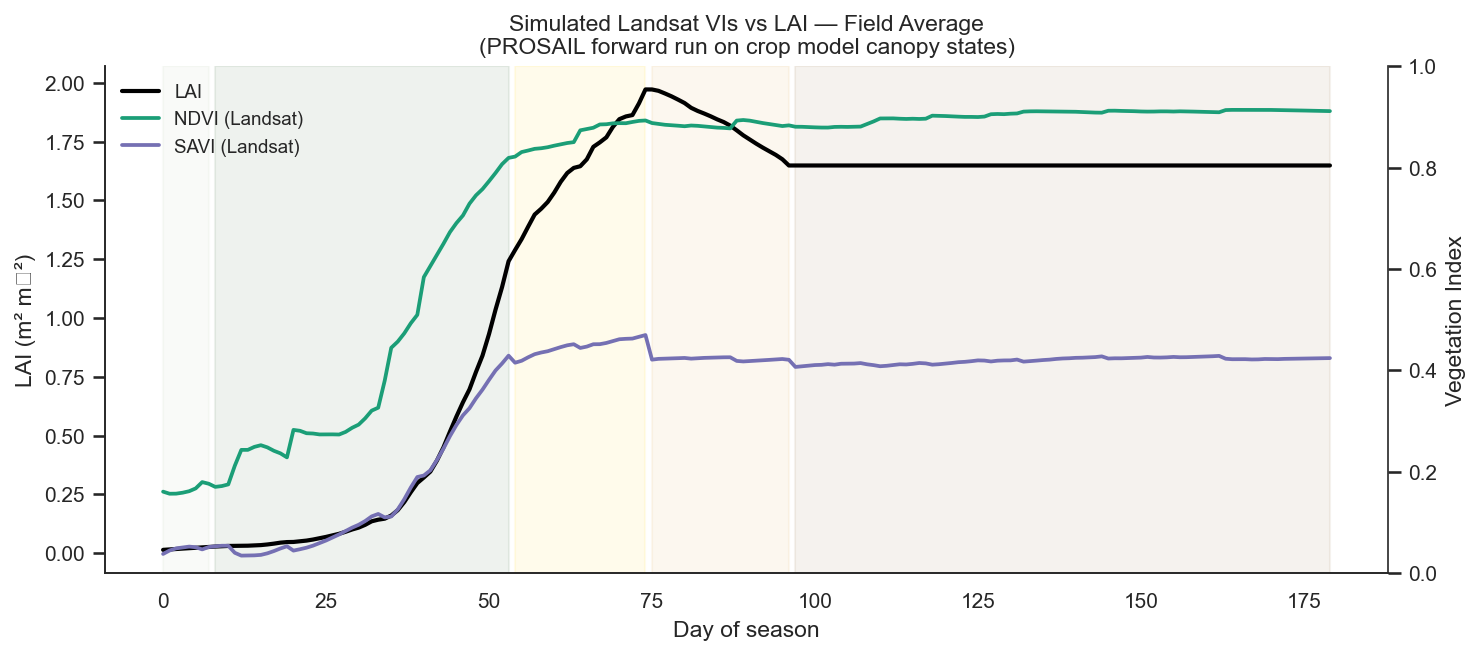

In [25]:
# ── Plot 7.1: Temporal — LAI + Landsat VIs ───────────────────────────────────
if PROSAIL_AVAILABLE:
    spec = df_out.groupby("day")[["LAI","NDVI","SAVI"]].mean()

    fig, ax1 = plt.subplots(figsize=(10, 4.5))
    ax1.plot(spec.index, spec["LAI"], color="black", lw=2, label="LAI")
    ax1.set_xlabel("Day of season"); ax1.set_ylabel("LAI (m² m⁻²)")

    ax2 = ax1.twinx()
    ax2.plot(spec.index, spec["NDVI"], color="#1b9e77", label="NDVI (Landsat)")
    ax2.plot(spec.index, spec["SAVI"], color="#7570b3", label="SAVI (Landsat)")
    ax2.set_ylabel("Vegetation Index"); ax2.set_ylim(0, 1)

    add_stage_shading([ax1], df_out)
    lines  = ax1.get_lines() + ax2.get_lines()
    labels = [l.get_label() for l in lines]
    ax2.legend(lines, labels, loc="upper left", frameon=False, fontsize=9)
    sns.despine(ax=ax1); sns.despine(ax=ax2, right=False)
    plt.title("Simulated Landsat VIs vs LAI — Field Average\n"
              "(PROSAIL forward run on crop model canopy states)", fontsize=11)
    plt.tight_layout(); plt.show()


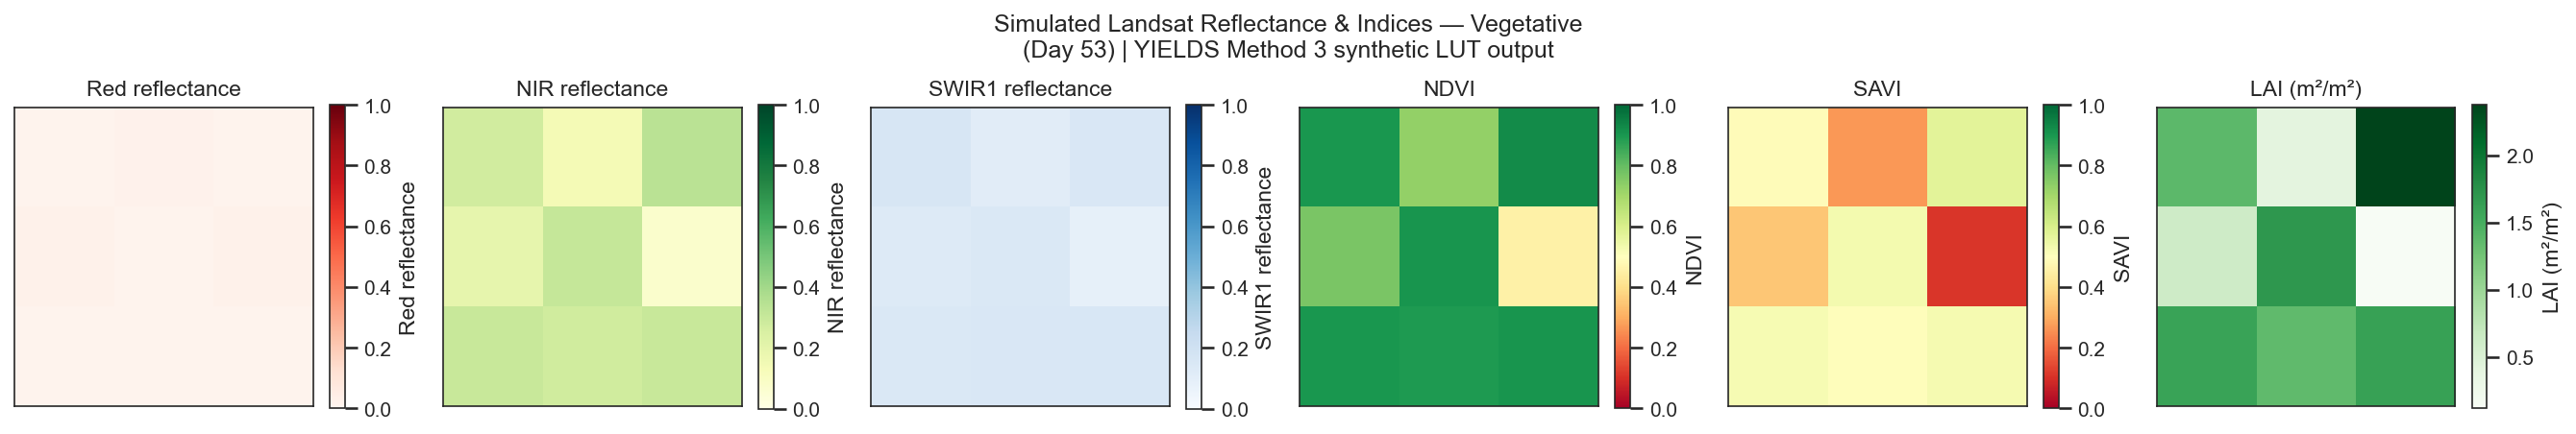

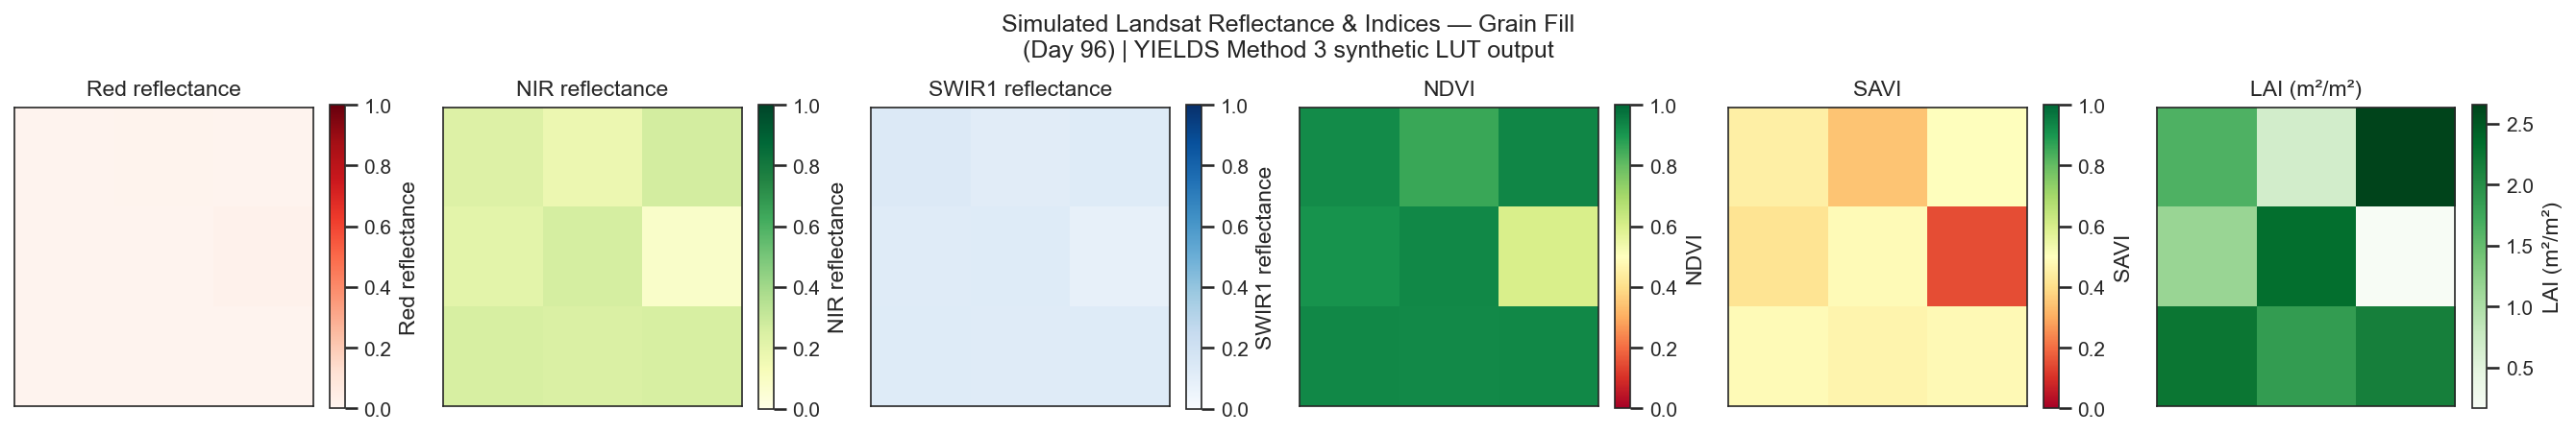

In [28]:
# ── Plot 7.2: Spatial — Landsat band + index maps per stage ──────────────────
if PROSAIL_AVAILABLE:
    for stage_focus in ["vegetative", "grain_fill"]:
        sub    = df_out[df_out["stage"] == stage_focus]
        if sub.empty: continue
        df_day = df_out[df_out["day"] == sub["day"].max()]

        fig, axes = plt.subplots(1, 6, figsize=(18, 3))
        specs = [
            ("red",   "Reds",   "Red reflectance"),
            ("nir",   "YlGn",   "NIR reflectance"),
            ("swir16","Blues",  "SWIR1 reflectance"),
            ("NDVI",  "RdYlGn", "NDVI"),
            ("SAVI",  "RdYlGn", "SAVI"),
            ("LAI",   "Greens", "LAI (m²/m²)"),
        ]
        for ax, (var, cmap, label) in zip(axes.flat, specs):
            grid = df_day.pivot(index="i", columns="j", values=var)
            vmin, vmax = (0, 1) if var in ("NDVI","SAVI","red","nir","swir16") else (grid.min().min(), grid.max().max())
            im   = ax.imshow(grid, cmap=cmap, interpolation="nearest", vmin=vmin, vmax=vmax)
            plt.colorbar(im, ax=ax, fraction=0.046, label=label)
            ax.set_title(label, fontsize=11); ax.set_xticks([]); ax.set_yticks([])

        plt.suptitle(
            f"Simulated Landsat Reflectance & Indices — {stage_focus.replace('_',' ').title()}\n"
            f"(Day {sub['day'].max()}) | YIELDS Method 3 synthetic LUT output",
            fontsize=12)
        plt.tight_layout(); plt.show()


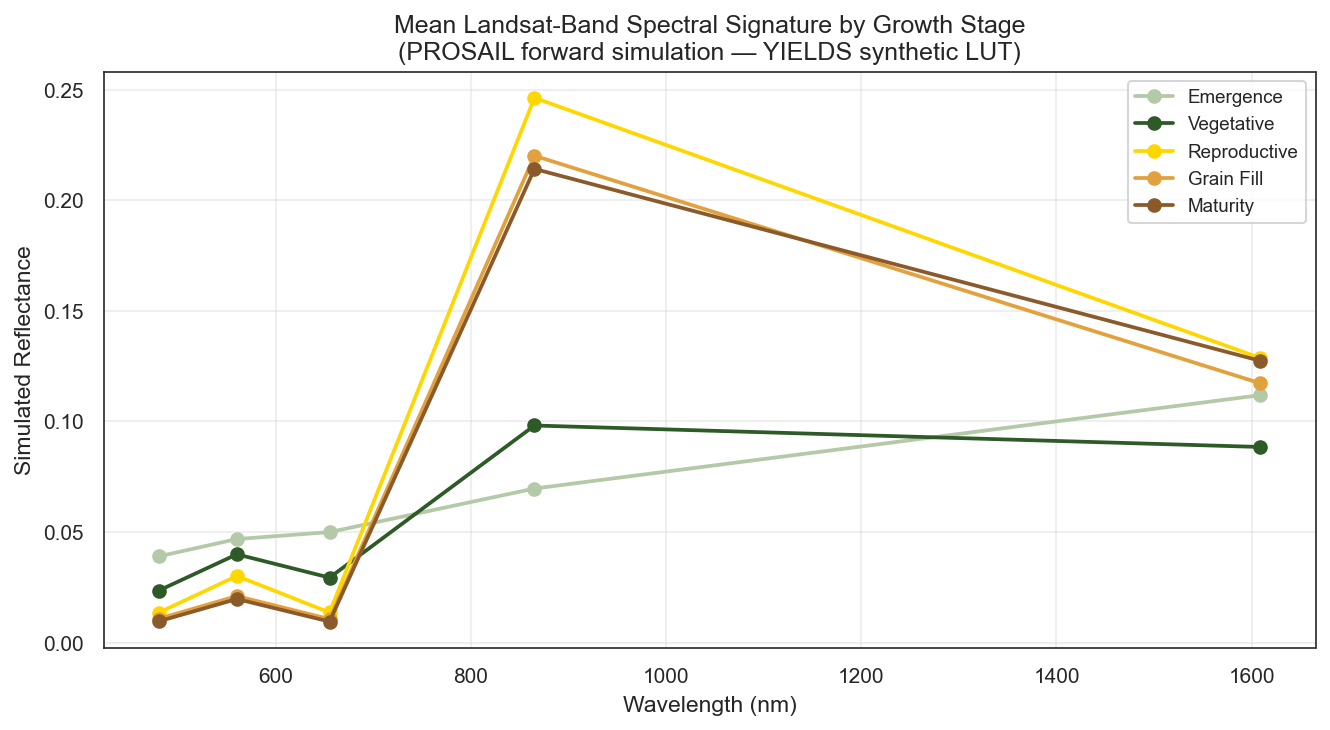

In [29]:
# ── Plot 7.3: Spectral signature by growth stage ──────────────────────────────
if PROSAIL_AVAILABLE:
    wl_centers = {"blue": 480, "green": 560, "red": 655,
                  "nir": 865, "swir16": 1609}
    stage_order = ["emergence","vegetative","reproductive","grain_fill","maturity"]

    fig, ax = plt.subplots(figsize=(9, 5))
    for stage in stage_order:
        sub = df_out[df_out["stage"] == stage]
        if sub.empty: continue
        means = {b: sub[b].mean() for b in wl_centers}
        xs    = list(wl_centers.values())
        ys    = list(means.values())
        ax.plot(xs, ys, "o-", color=stage_colors.get(stage,"grey"),
                label=stage.replace("_"," ").title(), lw=1.8, ms=6)

    ax.set_xlabel("Wavelength (nm)"); ax.set_ylabel("Simulated Reflectance")
    ax.set_title("Mean Landsat-Band Spectral Signature by Growth Stage\n"
                 "(PROSAIL forward simulation — YIELDS synthetic LUT)")
    ax.legend(fontsize=9); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()


---
## Section 8 — End-of-Season Summary

In [30]:
final_day = df["day"].max()
df_final  = df[df["day"] == final_day]

print("=" * 55)
print(f" END-OF-SEASON SUMMARY  (Day {final_day})")
print("=" * 55)
summary_vars = ["Biomass","Grain","LAI","VWC","f_water","theta_fc","theta_wp"]
print(df_final[summary_vars].describe().round(3).to_string())

print("\nSpatial coefficient of variation (CV):")
for var in summary_vars:
    mu = df_final[var].mean()
    cv = df_final[var].std() / mu * 100 if mu != 0 else 0
    print(f"  {var:>15}: {cv:5.1f}%")


 END-OF-SEASON SUMMARY  (Day 179)
        Biomass     Grain    LAI    VWC  f_water  theta_fc  theta_wp
count     9.000     9.000  9.000  9.000    9.000     9.000     9.000
mean   1238.259   756.309  1.648  0.161    0.947     0.294     0.157
std     563.200   332.888  0.829  0.047    0.109     0.043     0.036
min     141.138    92.977  0.163  0.070    0.704     0.186     0.089
25%    1050.873   592.810  1.153  0.143    1.000     0.297     0.149
50%    1436.142   886.642  1.865  0.182    1.000     0.298     0.151
75%    1650.890   989.964  2.242  0.186    1.000     0.300     0.154
max    1800.033  1066.308  2.655  0.211    1.000     0.335     0.210

Spatial coefficient of variation (CV):
          Biomass:  45.5%
            Grain:  44.0%
              LAI:  50.3%
              VWC:  29.1%
          f_water:  11.5%
         theta_fc:  14.8%
         theta_wp:  23.1%


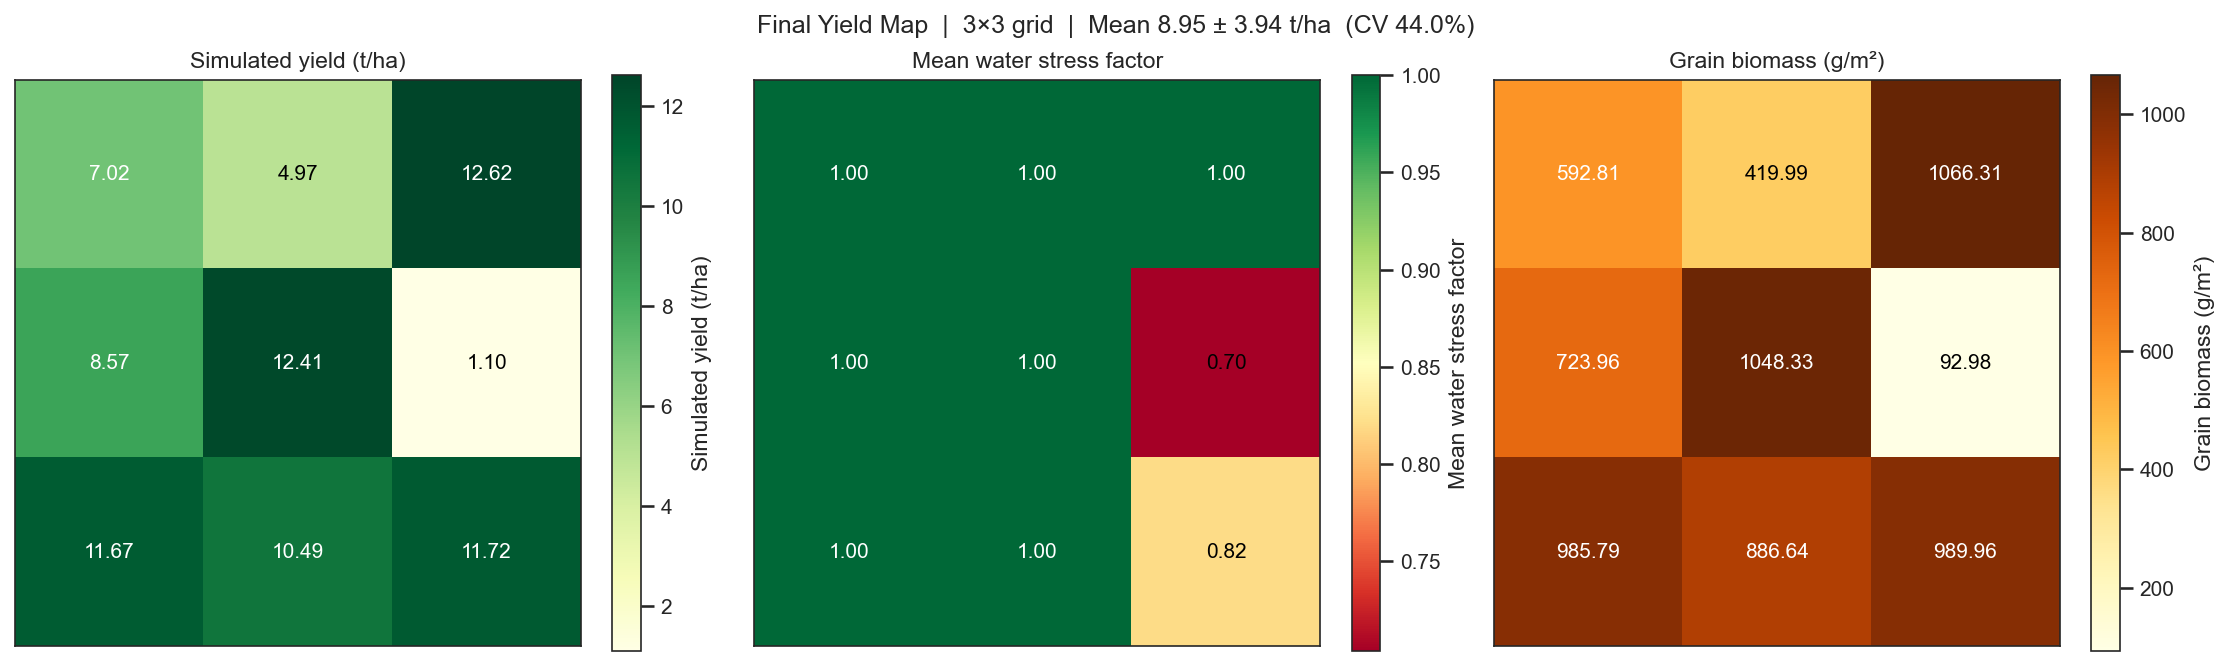

In [31]:
# ── Final yield spatial map ───────────────────────────────────────────────────
# Converts grain biomass (g/m²) → yield (t/ha) at 15.5% standard moisture.
GRAIN_MOISTURE   = 0.155
df_final         = df_final.copy()
df_final["yield_t_ha"] = df_final["Grain"] * 0.01 / (1 - GRAIN_MOISTURE)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (var, cmap, label) in zip(axes, [
    ("yield_t_ha", "YlGn",   "Simulated yield (t/ha)"),
    ("f_water",    "RdYlGn", "Mean water stress factor"),
    ("Grain",      "YlOrBr", "Grain biomass (g/m²)"),
]):
    grid = df_final.pivot(index="i", columns="j", values=var)
    vmin, vmax = grid.min().min(), grid.max().max()
    im = ax.imshow(grid, cmap=cmap, interpolation="nearest", vmin=vmin, vmax=vmax)
    plt.colorbar(im, ax=ax, label=label, fraction=0.046)
    for r in range(grid.shape[0]):
        for c in range(grid.shape[1]):
            v = grid.iloc[r, c]
            ax.text(c, r, f"{v:.2f}", ha="center", va="center", fontsize=10,
                    color="white" if v > (vmin+vmax)/2 else "black")
    ax.set_title(label, fontsize=11); ax.set_xticks([]); ax.set_yticks([])

yv = df_final["yield_t_ha"]
plt.suptitle(
    f"Final Yield Map  |  {GRID_ROWS}×{GRID_COLS} grid  |  "
    f"Mean {yv.mean():.2f} ± {yv.std():.2f} t/ha  "
    f"(CV {yv.std()/yv.mean()*100:.1f}%)", fontsize=12)
plt.tight_layout(); plt.show()
